# Robustness to Decomposition and Sampling



## Robustness Setup A: Decomposition and Sampling

This cell visualizes the first decomposition/sampling configuration used for the robustness study.


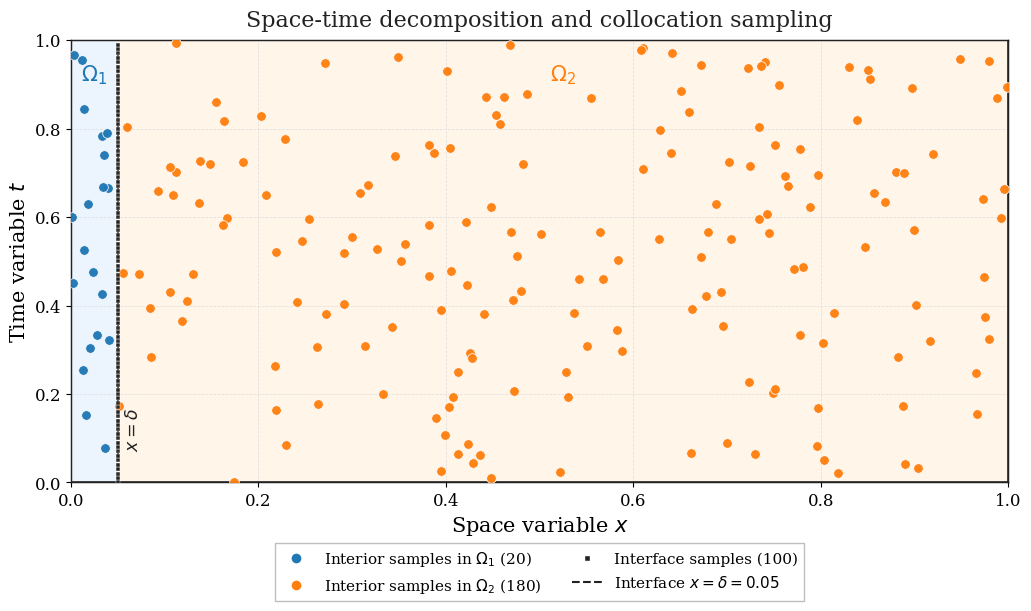

In [ ]:
# @title Robustness setup A: decomposition and sampling
# Purpose: Visualize the decomposition and sampling points for this robustness setup.

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def plot_ddm_sampling_q1(
    xt_int1,
    xt_int2,
    xt_if_all,
    delta,
    L=1.0,
    Tmin=0.0,
    Tmax=1.0,
    save_path=None,
    show=True,
    dpi=400
):
    """
    Q1-style plot of the space-time decomposition and sampling points
    using the same Omega1/Omega2 colors as your usual plots.
    """

    def to_numpy(a):
        if hasattr(a, "detach"):
            return a.detach().cpu().numpy()
        return np.asarray(a)

    pts1 = to_numpy(xt_int1)
    pts2 = to_numpy(xt_int2)
    pts_if = to_numpy(xt_if_all)

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 13,
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 11,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.1,
        "savefig.dpi": dpi,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    c1 = "#1f77b4"
    c2 = "#ff7f0e"
    cif = "#222222"
    cax = "#222222"
    cgrid = "#d9d9d9"

    bg1 = "#dbeafe"
    bg2 = "#ffedd5"

    fig, ax = plt.subplots(figsize=(10.2, 6.0), constrained_layout=True)

    ax.add_patch(Rectangle((0.0, Tmin), delta, Tmax - Tmin,
                           facecolor=bg1, edgecolor="none", alpha=0.50, zorder=0))
    ax.add_patch(Rectangle((delta, Tmin), L - delta, Tmax - Tmin,
                           facecolor=bg2, edgecolor="none", alpha=0.50, zorder=0))

    ax.plot([0, L, L, 0, 0],
            [Tmin, Tmin, Tmax, Tmax, Tmin],
            color=cax, linewidth=1.15, zorder=1)

    ax.axvline(delta, color=cax, linestyle="--", linewidth=1.5, zorder=2)

    ax.scatter(
        pts1[:, 0], pts1[:, 1],
        s=48, marker="o",
        facecolor=c1, edgecolor="white", linewidth=0.55,
        alpha=0.96, zorder=3, rasterized=True
    )

    ax.scatter(
        pts2[:, 0], pts2[:, 1],
        s=48, marker="o",
        facecolor=c2, edgecolor="white", linewidth=0.55,
        alpha=0.96, zorder=3, rasterized=True
    )

    ax.scatter(
        pts_if[:, 0], pts_if[:, 1],
        s=12, marker="s",
        facecolor=cif, edgecolor="white", linewidth=0.30,
        alpha=0.92, zorder=4, rasterized=True
    )

    ax.text(
        0.5 * delta, Tmax - 0.05 * (Tmax - Tmin),
        r"$\Omega_1$",
        color=c1, fontsize=15, fontweight="semibold",
        ha="center", va="top"
    )

    ax.text(
        delta + 0.5 * (L - delta), Tmax - 0.05 * (Tmax - Tmin),
        r"$\Omega_2$",
        color=c2, fontsize=15, fontweight="semibold",
        ha="center", va="top"
    )

    ax.text(
        delta + 0.008 * L, Tmin + 0.07 * (Tmax - Tmin),
        r"$x=\delta$",
        color=cax, fontsize=12.5,
        ha="left", va="bottom", rotation=90
    )

    ax.set_xlim(0.0, L)
    ax.set_ylim(Tmin, Tmax)
    ax.set_xlabel(r"Space variable $x$")
    ax.set_ylabel(r"Time variable $t$")
    ax.set_xticks(np.linspace(0, L, 6))
    ax.set_yticks(np.linspace(Tmin, Tmax, 6))

    ax.grid(True, which="major", linestyle="--", linewidth=0.55, color=cgrid, alpha=0.75)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_color(cax)
        spine.set_linewidth(1.05)

    ax.set_title(r"Space-time decomposition and collocation sampling", pad=10, color=cax)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=c1, markeredgecolor='white',
               markersize=8, label=fr'Interior samples in $\Omega_1$ ({len(pts1)})'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=c2, markeredgecolor='white',
               markersize=8, label=fr'Interior samples in $\Omega_2$ ({len(pts2)})'),
        Line2D([0], [0], marker='s', color='w',
               markerfacecolor=cif, markeredgecolor='white',
               markersize=5.0, label=fr'Interface samples ({len(pts_if)})'),
        Line2D([0], [0], color=cax, lw=1.5, linestyle='--',
               label=fr'Interface $x=\delta={delta:.2f}$')
    ]

    leg = ax.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        frameon=True,
        fancybox=False,
        edgecolor="#bfbfbf"
    )
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_alpha(1.0)

    if save_path is not None:
        folder = os.path.dirname(save_path)
        if folder:
            os.makedirs(folder, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
plot_ddm_sampling_q1(
    xt_int1=xt_int1,
    xt_int2=xt_int2,
    xt_if_all=xt_if_all,
    delta=delta,
    L=L,
    Tmin=Tmin,
    Tmax=Tmax,
    save_path="checkpoints/ddm_sampling_q1.png",
    show=True
)


## Setup A: Nonlocal Operator

This cell trains the nonlocal optimized Schwarz PINN for the first robustness setup.


In [ ]:
# @title Robustness setup A: nonlocal operator approximation
# Purpose: Train the nonlocal optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.05
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 20,180
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 15.984 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 30.403 s
r1=2.200e+00  r2=6.072e-02  (max=2.200e+00)
[iter 1] L2(u)=9.485e-03  L2(v)=6.310e-03
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=9.782e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 15.696 s
r1=4.232e-02  r2=6.842e-02  (max=6.842e-02)
[iter 2] L2(u)=2.132e-03  L2(v)=3.069e-03
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=2.699e-03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 15.571 s
r1=8.766e-02  r2=2.634e-03  (max=8.766e-02)
[iter 3] L2(u)=1.363e-03  L2(v)=1.317e-03
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.685e-03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 15.548 s
r1=1.029e-02  r2=4.043e-03  (max=1.029e-02)
[iter 4] L2(u)=6.481e-04  L2(v)=6.633e-04
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=5.034e-04
Converged (global-in-time) by tolerance.

[Timing] D

## Setup A: Local Approximation Order 0

This cell trains the order-0 local approximation for the first robustness setup.


In [ ]:
# @title Robustness setup A: local operator approximation order 0
# Purpose: Train the order-0 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.05
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order0(a: float, sign: float):
    a = float(a)
    return sign * (1.0 / a)

C0_1 = dtn_coeffs_order0(a2, +1.0)
C0_2 = dtn_coeffs_order0(a1, -1.0)

def interface_LHS_order0(net, xt_if_all, c0):
    """
    LHS = ∂_x z + c0 z, with z=(u,v)
    Returns (lhs, out).
    """
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u = out[:, 0:1]; v = out[:, 1:2]
    gu = torch.autograd.grad(u, xtg, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xtg, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xtg)
    if gv is None: gv = torch.zeros_like(xtg)

    u_x = gu[:, 0:1]
    v_x = gv[:, 0:1]
    du  = torch.cat([u_x, v_x], dim=1)

    return du + c0 * out, out

def build_target_from_other_order0(net_other, xt_if_all, c0):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u = out[:, 0:1]; v = out[:, 1:2]
    gu = torch.autograd.grad(u, xtg, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xtg, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xtg)
    if gv is None: gv = torch.zeros_like(xtg)

    u_x = gu[:, 0:1]
    v_x = gv[:, 0:1]
    du  = torch.cat([u_x, v_x], dim=1)

    return (du + c0 * out).detach()

def apply_L_from_out_order0(out, xt, c0):
    u = out[:, 0:1]; v = out[:, 1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)

    u_x = gu[:, 0:1]
    v_x = gv[:, 0:1]
    du  = torch.cat([u_x, v_x], dim=1)
    return du + c0 * out

def interface_metrics_order0(z1, z2, xt_if_all, c0_1, c0_2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order0(out1, xtg, c0_1)
    L1_z2 = apply_L_from_out_order0(out2, xtg, c0_1)
    L2_z2 = apply_L_from_out_order0(out2, xtg, c0_2)
    L2_z1 = apply_L_from_out_order0(out1, xtg, c0_2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 20,180
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order0(net, xt_if_all, C0_1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order0(net, xt_if_all, C0_2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order0(z2, xt_if_all, C0_1)
    target_R2_full = build_target_from_other_order0(z1, xt_if_all, C0_2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order0(z1, z2, xt_if_all, C0_1, C0_2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 8.603 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 10.558 s
r1=1.455e+06  r2=7.659e+04  (max=1.455e+06)
[iter 1] L2(u)=2.182e+05  L2(v)=3.273e+05
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.029e+05

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 4.970 s
r1=8.958e+05  r2=4.715e+04  (max=8.958e+05)
[iter 2] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.335e+04

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 4.307 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 3] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 5.605 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 4] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iterati

## Setup A: Local Approximation Order 1

This cell trains the order-1 local approximation for the first robustness setup.


In [ ]:
# @title Robustness setup A: local operator approximation order 1
# Purpose: Train the order-1 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.05
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order1(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    return (c0, c1)

COEFF1 = dtn_coeffs_order1(L - delta, +1.0)
COEFF2 = dtn_coeffs_order1(delta,     -1.0)

def interface_LHS_order1(net, xt_if_all, coeffs):
    """
    L(z) = ∂_x z + c0 z + J * ( (-c1) z_t )
    where Λ ≈ c0 + c1 ω and ω ↔ -i∂_t.
    """
    c0, c1 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    du   = torch.cat([u_x, v_x], dim=1)
    z_t  = torch.cat([u_t, v_t], dim=1)

    Ra  = c0 * out
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order1(net_other, xt_if_all, coeffs):
    c0, c1 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    du   = torch.cat([u_x, v_x], dim=1)
    z_t  = torch.cat([u_t, v_t], dim=1)

    Ra  = c0 * out
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order1(out, xt, coeffs):
    c0, c1 = coeffs
    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    du   = torch.cat([u_x, v_x], dim=1)
    z_t  = torch.cat([u_t, v_t], dim=1)

    Ra  = c0 * out
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order1(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order1(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order1(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order1(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order1(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 20,180
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order1(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order1(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order1(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order1(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order1(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 9.590 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.370 s
r1=nan  r2=nan  (max=nan)
[iter 1] L2(u)=nan  L2(v)=nan
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=nan

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

## Setup A: Local Approximation Order 2

This cell trains the order-2 local approximation for the first robustness setup.


In [ ]:
# @title Robustness setup A: local operator approximation order 2
# Purpose: Train the order-2 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.05
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order2(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    c2 = sign * (-(a**3) / 45.0)
    return (c0, c1, c2)

COEFF1 = dtn_coeffs_order2(L - delta, +1.0)
COEFF2 = dtn_coeffs_order2(delta,     -1.0)

def _time_second(w_t, xt):
    """Given w_t, return w_tt using autograd (xt requires_grad=True)."""
    g = torch.autograd.grad(w_t, xt, torch.ones_like(w_t),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_t)
    return g[:, 1:2]

def interface_LHS_order2(net, xt_if_all, coeffs):
    """
    LHS = ∂_x z + (c0 z - c2 z_tt) + J * ( (-c1) z_t )
    """
    c0, c1, c2 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)

    du    = torch.cat([u_x,  v_x],  dim=1)
    z_t   = torch.cat([u_t,  v_t],  dim=1)
    z_tt  = torch.cat([u_tt, v_tt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order2(net_other, xt_if_all, coeffs):
    c0, c1, c2 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)

    du    = torch.cat([u_x,  v_x],  dim=1)
    z_t   = torch.cat([u_t,  v_t],  dim=1)
    z_tt  = torch.cat([u_tt, v_tt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order2(out, xt, coeffs):
    """Same operator as above, but you already have out=net(xt)."""
    c0, c1, c2 = coeffs

    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    u_tt = _time_second(u_t, xt)
    v_tt = _time_second(v_t, xt)

    du    = torch.cat([u_x,  v_x],  dim=1)
    z_t   = torch.cat([u_t,  v_t],  dim=1)
    z_tt  = torch.cat([u_tt, v_tt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order2(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order2(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order2(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order2(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order2(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 20,180
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order2(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order2(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order2(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order2(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order2(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 7.162 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.802 s
r1=2.023e+05  r2=1.065e+04  (max=2.023e+05)
[iter 1] L2(u)=5.455e+04  L2(v)=3.409e+03
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.430e+04

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 8.908 s
r1=1.377e+05  r2=7.250e+03  (max=1.377e+05)
[iter 2] L2(u)=4.092e+04  L2(v)=1.023e+04
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=9.737e+03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 9.787 s
r1=8.744e+04  r2=4.602e+03  (max=8.744e+04)
[iter 3] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.181e+03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 6.051 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 4] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iterati

## Setup A: Local Approximation Order 3

This cell trains the order-3 local approximation for the first robustness setup.


In [ ]:
# @title Robustness setup A: local operator approximation order 3
# Purpose: Train the order-3 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.05
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order3(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    c2 = sign * (-(a**3) / 45.0)
    c3 = sign * (-(2.0 * a**5) / 945.0)
    return (c0, c1, c2, c3)

COEFF1 = dtn_coeffs_order3(L - delta, +1.0)
COEFF2 = dtn_coeffs_order3(delta,     -1.0)

def _time_second(w_t, xt):
    g = torch.autograd.grad(w_t, xt, torch.ones_like(w_t),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_t)
    return g[:, 1:2]

def _time_third(w_tt, xt):
    g = torch.autograd.grad(w_tt, xt, torch.ones_like(w_tt),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_tt)
    return g[:, 1:2]

def interface_LHS_order3(net, xt_if_all, coeffs):
    """
    LHS = ∂_x z + (c0 z - c2 z_tt) + J * ( (-c1) z_t + c3 z_ttt )
    """
    c0, c1, c2, c3 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)

    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)

    u_ttt = _time_third(u_tt, xtg)
    v_ttt = _time_third(v_tt, xtg)

    du     = torch.cat([u_x,   v_x],   dim=1)
    z_t    = torch.cat([u_t,   v_t],   dim=1)
    z_tt   = torch.cat([u_tt,  v_tt],  dim=1)
    z_ttt  = torch.cat([u_ttt, v_ttt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order3(net_other, xt_if_all, coeffs):
    c0, c1, c2, c3 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)
    u_ttt = _time_third(u_tt, xtg)
    v_ttt = _time_third(v_tt, xtg)

    du    = torch.cat([u_x,   v_x],   dim=1)
    z_t   = torch.cat([u_t,   v_t],   dim=1)
    z_tt  = torch.cat([u_tt,  v_tt],  dim=1)
    z_ttt = torch.cat([u_ttt, v_ttt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order3(out, xt, coeffs):
    """Same operator, but out=net(xt) already computed."""
    c0, c1, c2, c3 = coeffs

    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    u_tt = _time_second(u_t, xt)
    v_tt = _time_second(v_t, xt)
    u_ttt = _time_third(u_tt, xt)
    v_ttt = _time_third(v_tt, xt)

    du    = torch.cat([u_x,   v_x],   dim=1)
    z_t   = torch.cat([u_t,   v_t],   dim=1)
    z_tt  = torch.cat([u_tt,  v_tt],  dim=1)
    z_ttt = torch.cat([u_ttt, v_ttt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order3(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order3(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order3(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order3(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order3(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 20,180
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order3(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order3(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order3(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order3(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order3(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 8.674 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 33.242 s
r1=nan  r2=nan  (max=nan)
[iter 1] L2(u)=nan  L2(v)=nan
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=nan

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

## Setup A: Local Approximation Order 4

This cell trains the order-4 local approximation for the first robustness setup.


In [ ]:
# @title Robustness setup A: local operator approximation order 4
# Purpose: Train the order-4 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.05
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order4(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    c2 = sign * (-(a**3) / 45.0)
    c3 = sign * (-(2.0 * a**5) / 945.0)
    c4 = sign * (-(a**7) / 4725.0)
    return (c0, c1, c2, c3, c4)

COEFF1 = dtn_coeffs_order4(L - delta, +1.0)
COEFF2 = dtn_coeffs_order4(delta,     -1.0)

def _time_second(w_t, xt):
    g = torch.autograd.grad(w_t, xt, torch.ones_like(w_t),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_t)
    return g[:, 1:2]

def _time_third(w_tt, xt):
    g = torch.autograd.grad(w_tt, xt, torch.ones_like(w_tt),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_tt)
    return g[:, 1:2]

def _time_fourth(w_ttt, xt):
    g = torch.autograd.grad(w_ttt, xt, torch.ones_like(w_ttt),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_ttt)
    return g[:, 1:2]

def interface_LHS_order4(net, xt_if_all, coeffs):
    """
    LHS = ∂_x z + (c0 z - c2 z_tt + c4 z_tttt) + J * ( (-c1) z_t + c3 z_ttt )
    """
    c0, c1, c2, c3, c4 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt  = _time_second(u_t,  xtg)
    v_tt  = _time_second(v_t,  xtg)
    u_ttt = _time_third(u_tt,  xtg)
    v_ttt = _time_third(v_tt,  xtg)
    u_tttt = _time_fourth(u_ttt, xtg)
    v_tttt = _time_fourth(v_ttt, xtg)

    du     = torch.cat([u_x,    v_x],    dim=1)
    z_t    = torch.cat([u_t,    v_t],    dim=1)
    z_tt   = torch.cat([u_tt,   v_tt],   dim=1)
    z_ttt  = torch.cat([u_ttt,  v_ttt],  dim=1)
    z_tttt = torch.cat([u_tttt, v_tttt], dim=1)

    Ra  = c0 * out - c2 * z_tt + c4 * z_tttt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order4(net_other, xt_if_all, coeffs):
    c0, c1, c2, c3, c4 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt  = _time_second(u_t,  xtg)
    v_tt  = _time_second(v_t,  xtg)
    u_ttt = _time_third(u_tt,  xtg)
    v_ttt = _time_third(v_tt,  xtg)
    u_tttt = _time_fourth(u_ttt, xtg)
    v_tttt = _time_fourth(v_ttt, xtg)

    du     = torch.cat([u_x,    v_x],    dim=1)
    z_t    = torch.cat([u_t,    v_t],    dim=1)
    z_tt   = torch.cat([u_tt,   v_tt],   dim=1)
    z_ttt  = torch.cat([u_ttt,  v_ttt],  dim=1)
    z_tttt = torch.cat([u_tttt, v_tttt], dim=1)

    Ra  = c0 * out - c2 * z_tt + c4 * z_tttt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order4(out, xt, coeffs):
    c0, c1, c2, c3, c4 = coeffs

    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    u_tt  = _time_second(u_t,  xt)
    v_tt  = _time_second(v_t,  xt)
    u_ttt = _time_third(u_tt,  xt)
    v_ttt = _time_third(v_tt,  xt)
    u_tttt = _time_fourth(u_ttt, xt)
    v_tttt = _time_fourth(v_ttt, xt)

    du     = torch.cat([u_x,    v_x],    dim=1)
    z_t    = torch.cat([u_t,    v_t],    dim=1)
    z_tt   = torch.cat([u_tt,   v_tt],   dim=1)
    z_ttt  = torch.cat([u_ttt,  v_ttt],  dim=1)
    z_tttt = torch.cat([u_tttt, v_tttt], dim=1)

    Ra  = c0 * out - c2 * z_tt + c4 * z_tttt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order4(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order4(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order4(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order4(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order4(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 20,180
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order4(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order4(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order4(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order4(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order4(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 7.039 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 71.627 s
r1=nan  r2=nan  (max=nan)
[iter 1] L2(u)=nan  L2(v)=nan
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=nan

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

## Setup A: Stored Logs

This cell stores the logs for the first robustness setup so the comparison can be reproduced without retraining.


In [ ]:
# @title Robustness setup A: logs for all operator approximations
# Purpose: Store raw logs for the local and nonlocal operator approximations.

LOGS = {
   "Nonlocal": """ Device : cpu
[Timing] Warm-start total (parallel): 15.984 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 30.403 s
r1=2.200e+00  r2=6.072e-02  (max=2.200e+00)
[iter 1] L2(u)=9.485e-03  L2(v)=6.310e-03
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=9.782e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 15.696 s
r1=4.232e-02  r2=6.842e-02  (max=6.842e-02)
[iter 2] L2(u)=2.132e-03  L2(v)=3.069e-03
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=2.699e-03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 15.571 s
r1=8.766e-02  r2=2.634e-03  (max=8.766e-02)
[iter 3] L2(u)=1.363e-03  L2(v)=1.317e-03
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.685e-03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 15.548 s
r1=1.029e-02  r2=4.043e-03  (max=1.029e-02)
[iter 4] L2(u)=6.481e-04  L2(v)=6.633e-04
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=5.034e-04
Converged (global-in-time) by tolerance.

[Timing] Decomposed (z1/z2) total: 97.477 s (warm-start 15.984 s, Schwarz 81.493 s)
[Timing] Schwarz per-iter: avg 19.304 s, min 15.548 s, max 30.403 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt
""",
   "Local O0": """Device : cpu
[Timing] Warm-start total (parallel): 8.603 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 10.558 s
r1=1.455e+06  r2=7.659e+04  (max=1.455e+06)
[iter 1] L2(u)=2.182e+05  L2(v)=3.273e+05
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.029e+05

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 4.970 s
r1=8.958e+05  r2=4.715e+04  (max=8.958e+05)
[iter 2] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.335e+04

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 4.307 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 3] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 5.605 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 4] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 4.333 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 5] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 5] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 4.228 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 6] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 6] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 5.697 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 7] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 7] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 4.638 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 8] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 8] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 7.325 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 9] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 9] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 4.478 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 10] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 10] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 8.299 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 11] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 11] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 4.401 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 12] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 12] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 4.252 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 13] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 13] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 5.707 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 14] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 14] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 4.248 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 15] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 15] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 4.160 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 16] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 16] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 5.663 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 17] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 17] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 4.344 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 18] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 18] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 4.373 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 19] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 19] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 5.496 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 20] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 20] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 4.222 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 21] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 21] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 4.772 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 22] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 22] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 5.088 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 23] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 23] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 4.253 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 24] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 24] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 5.414 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 25] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 25] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 4.433 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 26] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 26] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 4.222 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 27] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 27] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 5.530 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 28] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 28] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 4.616 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 29] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 29] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 4.245 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 30] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 30] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 5.605 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 31] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 31] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 4.225 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 32] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 32] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 4.274 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 33] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 33] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 5.389 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 34] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 34] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 4.220 s
r1=8.192e+05  r2=4.312e+04  (max=8.192e+05)
[iter 35] L2(u)=2.182e+05  L2(v)=1.091e+05
[iter 35] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.793e+04

[Timing] Total: 187.368 s (warm-start 8.603 s, Schwarz 178.765 s)
[Timing] Schwarz per-iter: avg 5.074 s, min 4.160 s, max 10.558 s

Finished global-in-time Schwarz with local DtN order 0.
Saved final models to checkpoints/final_last_*.pt
 """,
   "Local O1": """ Device : cpu
[Timing] Warm-start total (parallel): 9.590 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.370 s
r1=nan  r2=nan  (max=nan)
[iter 1] L2(u)=nan  L2(v)=nan
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=nan""",
   "Local O2": """Device : cpu
[Timing] Warm-start total (parallel): 7.162 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.802 s
r1=2.023e+05  r2=1.065e+04  (max=2.023e+05)
[iter 1] L2(u)=5.455e+04  L2(v)=3.409e+03
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.430e+04

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 8.908 s
r1=1.377e+05  r2=7.250e+03  (max=1.377e+05)
[iter 2] L2(u)=4.092e+04  L2(v)=1.023e+04
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=9.737e+03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 9.787 s
r1=8.744e+04  r2=4.602e+03  (max=8.744e+04)
[iter 3] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.181e+03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 6.051 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 4] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 7.415 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 5] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 5] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 5.912 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 6] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 6] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 7.401 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 7] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 7] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 6.406 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 8] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 8] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 7.416 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 9] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 9] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 6.017 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 10] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 10] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 7.275 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 11] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 11] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 5.892 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 12] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 12] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 7.275 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 13] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 13] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 11.003 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 14] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 14] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 5.923 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 15] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 15] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 7.392 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 16] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 16] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 5.862 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 17] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 17] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 7.339 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 18] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 18] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 5.851 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 19] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 19] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 7.332 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 20] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 20] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 5.955 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 21] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 21] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 7.353 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 22] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 22] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 5.854 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 23] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 23] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 7.421 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 24] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 24] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 5.914 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 25] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 25] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 7.327 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 26] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 26] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 5.926 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 27] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 27] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 7.324 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 28] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 28] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 5.983 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 29] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 29] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 7.798 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 30] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 30] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 5.896 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 31] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 31] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 7.320 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 32] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 32] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 5.908 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 33] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 33] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 7.396 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 34] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 34] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 5.932 s
r1=9.234e+04  r2=4.860e+03  (max=9.234e+04)
[iter 35] L2(u)=2.728e+04  L2(v)=3.409e+03
[iter 35] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.527e+03

[Timing] Total: 260.329 s (warm-start 7.162 s, Schwarz 253.167 s)
[Timing] Schwarz per-iter: avg 7.188 s, min 5.851 s, max 15.802 s

Finished global-in-time Schwarz with local DtN order 0.
Saved final models to checkpoints/final_last_*.pt
""",
   "Local O3": """ Device : cpu
[Timing] Warm-start total (parallel): 8.674 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 33.242 s
r1=nan  r2=nan  (max=nan)
[iter 1] L2(u)=nan  L2(v)=nan
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=nan """,
   "Local O4": """  Device : cpu
[Timing] Warm-start total (parallel): 7.039 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 71.627 s
r1=nan  r2=nan  (max=nan)
[iter 1] L2(u)=nan  L2(v)=nan
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=nan""",
   }


## Setup A: Local vs Nonlocal Comparison

This cell parses the first setup logs and compares local versus nonlocal convergence behavior.


In [ ]:
# @title Robustness setup A: local vs nonlocal comparison
# Purpose: Parse stored logs and compare local versus nonlocal convergence behavior.

import re
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

TOL_L2MAX = 1e-3
TOL_JUMP  = 1e-3

re_warm = re.compile(r"\[Timing\]\s*Warm-start.*?:\s*([0-9]*\.?[0-9]+)\s*s", re.IGNORECASE)
re_iter_time = re.compile(r"\[Timing\]\s*Schwarz\s*iter\s*(\d+)\s*:\s*([0-9]*\.?[0-9]+)\s*s", re.IGNORECASE)
re_l2 = re.compile(r"\[iter\s*(\d+)\]\s*L2\(u\)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*L2\(v\)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", re.IGNORECASE)
re_r12 = re.compile(r"\br1\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*r2\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", re.IGNORECASE)

minus = r"(?:−|-)"
re_jump_local = re.compile(r"\[iter\s*(\d+)\].*?\|\|\s*z1.*?" + minus + r".*?z2.*?\|\|_L2\s*\(\s*0\s*,\s*T\s*\)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", re.IGNORECASE)
re_jump_nonlocal = re.compile(r"\[iter\s*(\d+)\].*?z1.*?" + minus + r".*?z2.*?\(t\)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", re.IGNORECASE)

def parse_log(text: str):
    m_w = re_warm.search(text)
    warm = float(m_w.group(1)) if m_w else 0.0

    it_time = {int(m.group(1)): float(m.group(2)) for m in re_iter_time.finditer(text)}
    it_l2u = {int(m.group(1)): float(m.group(2)) for m in re_l2.finditer(text)}
    it_l2v = {int(m.group(1)): float(m.group(3)) for m in re_l2.finditer(text)}
    it_jump = {int(m.group(1)): float(m.group(2)) for m in re_jump_local.finditer(text)}
    it_jump.update({int(m.group(1)): float(m.group(2)) for m in re_jump_nonlocal.finditer(text)})

    starts = [(m.start(), int(m.group(1))) for m in re.finditer(r"===\s*Schwarz iteration\s*(\d+)", text, flags=re.IGNORECASE)]
    it_r1, it_r2 = {}, {}
    for idx, (pos, it) in enumerate(starts):
        end = starts[idx + 1][0] if idx + 1 < len(starts) else len(text)
        block = text[pos:end]
        m_r = re_r12.search(block)
        if m_r:
            it_r1[it], it_r2[it] = float(m_r.group(1)), float(m_r.group(2))

    iters = sorted(set(it_time) | set(it_l2u) | set(it_l2v) | set(it_jump) | set(it_r1) | set(it_r2))

    rows = []
    for it in iters:
        u = it_l2u.get(it, np.nan)
        v = it_l2v.get(it, np.nan)
        l2max = np.nanmax([u, v]) if (not np.isnan(u) or not np.isnan(v)) else np.nan

        r1 = it_r1.get(it, np.nan)
        r2 = it_r2.get(it, np.nan)
        res = np.nanmax([r1, r2]) if (not np.isnan(r1) or not np.isnan(r2)) else np.nan

        rows.append({
            "iter": it,
            "time_iter_s": it_time.get(it, np.nan),
            "L2u": u,
            "L2v": v,
            "L2_max": l2max,
            "jump_L2": it_jump.get(it, np.nan),
            "r1": r1,
            "r2": r2,
            "res": res,
        })

    df = pd.DataFrame(rows).sort_values("iter").reset_index(drop=True)
    return df, warm

runs = {}
summary_rows = []

for name, txt in LOGS.items():
    df, warm = parse_log(txt)
    runs[name] = df

    sum_iter_time = float(df["time_iter_s"].sum(skipna=True))
    total_time = warm + sum_iter_time

    best_L2max  = float(df["L2_max"].min(skipna=True)) if df["L2_max"].notna().any() else np.nan
    best_jump   = float(df["jump_L2"].min(skipna=True)) if df["jump_L2"].notna().any() else np.nan
    best_res    = float(df["res"].min(skipna=True)) if df["res"].notna().any() else np.nan

    ok = (df["L2_max"] <= TOL_L2MAX) & (df["jump_L2"] <= TOL_JUMP)

    if ok.any():
        first_idx = int(np.argmax(ok.values))
        it_conv = int(df.loc[first_idx, "iter"])
        t_conv = warm + float(df.loc[df["iter"] <= it_conv, "time_iter_s"].sum(skipna=True))
        converged = True
    else:
        it_conv = None
        t_conv = None
        converged = False

    last_row = df.iloc[-1] if len(df) else None

    summary_rows.append({
        "Method": name,
        f"Converged (L2max<={TOL_L2MAX} & jump<={TOL_JUMP})": converged,
        "Iters to Converge": it_conv,
        "Time to Converge (s)": t_conv,
        "Warm-start (s)": warm,
        "Total Schwarz Time (s)": sum_iter_time,
        "Total Time (s)": total_time,
        "Avg Time/Iter (s)": float(df["time_iter_s"].mean(skipna=True)) if df["time_iter_s"].notna().any() else np.nan,
        "Best L2_max": best_L2max,
        "Best Jump_L2": best_jump,
        "Best res=max(r1,r2)": best_res,
        "Last L2_max": float(last_row["L2_max"]) if last_row is not None else np.nan,
        "Last Jump_L2": float(last_row["jump_L2"]) if last_row is not None else np.nan,
        "Last res=max(r1,r2)": float(last_row["res"]) if last_row is not None else np.nan,
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).set_index("Method")
else:
    summary_df = pd.DataFrame()

def plot_clean_lines(metric_name, ylabel, title, outdir="compare_runs_figs"):
    os.makedirs(outdir, exist_ok=True)
    plt.figure(figsize=(10, 6))

    colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#F0E442', '#000000']

    linestyles = ['-', '--', '-.', ':']

    styles = [(color, linestyle) for linestyle in linestyles for color in colors]
    style_cycler = itertools.cycle(styles)

    best_val = np.inf
    best_iter = None
    best_method = None

    for name, df in runs.items():
        if metric_name not in df.columns or df[metric_name].isna().all():
            continue

        color, linestyle = next(style_cycler)

        plt.semilogy(
            df["iter"],
            df[metric_name],
            label=name,
            color=color,
            linestyle=linestyle,
            linewidth=2.5 if name == "Nonlocal" else 2.0,
            alpha=0.85
        )

        method_min = df[metric_name].min(skipna=True)
        if method_min < best_val:
            best_val = method_min
            idx = df[metric_name].idxmin()
            best_iter = df.loc[idx, "iter"]
            best_method = name

    if best_val != np.inf and best_iter is not None:
        plt.plot(
            best_iter, best_val,
            marker='*',
            markersize=18,
            color='gold',
            markeredgecolor='black',
            linestyle='None',
            zorder=10,
            label=f"★ Best: {best_method} ({best_val:.2e})"
        )

    plt.xlabel("Schwarz Iteration", fontsize=12, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')

    if metric_name in ["L2_max", "jump_L2"]:
        tol_val = TOL_L2MAX if metric_name == "L2_max" else TOL_JUMP
        plt.axhline(y=tol_val, color='gray', linestyle='-', linewidth=1.5, alpha=0.5, zorder=0, label=f"Tol ({tol_val})")

    plt.grid(True, which="major", linestyle="-", alpha=0.3)
    plt.grid(True, which="minor", linestyle=":", alpha=0.2)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=11)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

if runs:

    print("\n=== Summary of Results ===")
    formatted = summary_df.copy()

    for col in ["Time to Converge (s)", "Warm-start (s)", "Total Schwarz Time (s)", "Total Time (s)", "Avg Time/Iter (s)"]:
        formatted[col] = formatted[col].apply(lambda x: f"{x:.2f}" if pd.notnull(x) else "N/A")
    for col in ["Best L2_max", "Best Jump_L2", "Best res=max(r1,r2)", "Last L2_max", "Last Jump_L2", "Last res=max(r1,r2)"]:
        formatted[col] = formatted[col].apply(lambda x: f"{x:.3e}" if pd.notnull(x) else "N/A")

    display(formatted)

    OUTDIR = "compare_runs_tables"
    os.makedirs(OUTDIR, exist_ok=True)
    summary_path = os.path.join(OUTDIR, "summary.csv")
    summary_df.to_csv(summary_path)

    for name, df in runs.items():
        df.to_csv(os.path.join(OUTDIR, f"history_{name}.csv"), index=False)

    print(f"\nSaved summary to: {summary_path}")
    print(f"Saved per-run histories to: {OUTDIR}/history_*.csv")
else:
    print("No data parsed. Please check your LOGS dictionary.")



=== Summary of Results ===


,Converged (L2max<=0.001 & jump<=0.001),Iters to Converge,Time to Converge (s),Warm-start (s),Total Schwarz Time (s),Total Time (s),Avg Time/Iter (s),Best L2_max,Best Jump_L2,"Best res=max(r1,r2)",Last L2_max,Last Jump_L2,"Last res=max(r1,r2)"
Method,,,,,,,,,,,,,
Nonlocal,True,4.0,93.20,15.98,77.22,93.20,19.30,6.633e-04,5.034e-04,1.029e-02,6.633e-04,5.034e-04,1.029e-02
Local O0,False,NaN,N/A,8.60,177.59,186.19,5.07,2.182e+05,5.793e+04,8.192e+05,2.182e+05,5.793e+04,8.192e+05
Local O1,False,NaN,N/A,9.59,19.37,28.96,19.37,N/A,N/A,N/A,N/A,N/A,N/A
Local O2,False,NaN,N/A,7.16,251.57,258.73,7.19,2.728e+04,6.181e+03,8.744e+04,2.728e+04,6.527e+03,9.234e+04
Local O3,False,NaN,N/A,8.67,33.24,41.92,33.24,N/A,N/A,N/A,N/A,N/A,N/A
Local O4,False,NaN,N/A,7.04,71.63,78.67,71.63,N/A,N/A,N/A,N/A,N/A,N/A



Saved summary to: compare_runs_tables/summary.csv
Saved per-run histories to: compare_runs_tables/history_*.csv


## Robustness Setup B: Decomposition and Sampling

This cell visualizes the second decomposition/sampling configuration used for the robustness study.


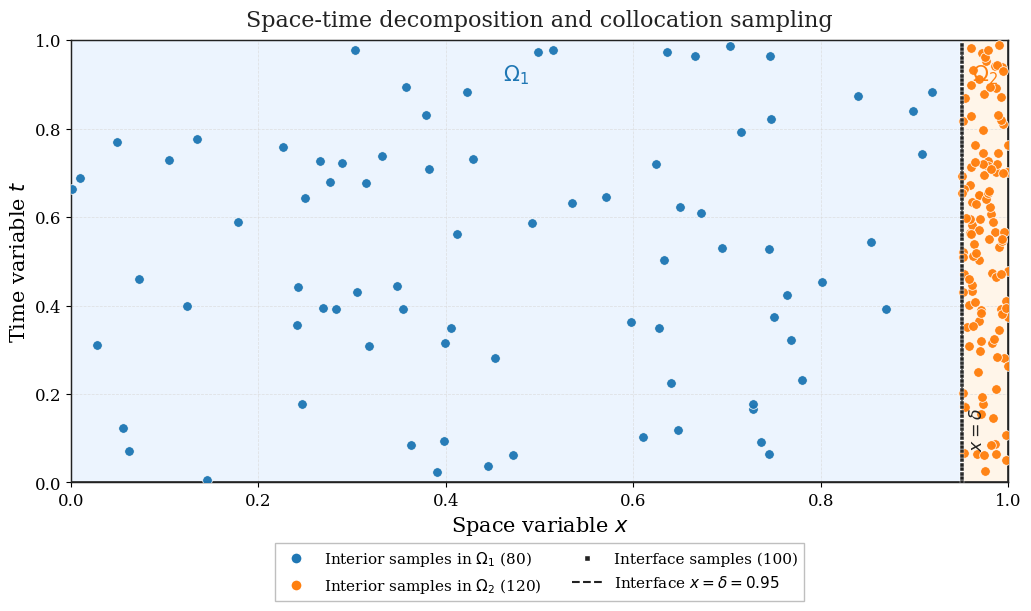

In [ ]:
# @title Robustness setup B: decomposition and sampling
# Purpose: Visualize the decomposition and sampling points for this robustness setup.

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def plot_ddm_sampling_q1(
    xt_int1,
    xt_int2,
    xt_if_all,
    delta,
    L=1.0,
    Tmin=0.0,
    Tmax=1.0,
    save_path=None,
    show=True,
    dpi=400
):
    """
    Q1-style plot of the space-time decomposition and sampling points
    using the same Omega1/Omega2 colors as your usual plots.
    """

    def to_numpy(a):
        if hasattr(a, "detach"):
            return a.detach().cpu().numpy()
        return np.asarray(a)

    pts1 = to_numpy(xt_int1)
    pts2 = to_numpy(xt_int2)
    pts_if = to_numpy(xt_if_all)

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 13,
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 11,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.1,
        "savefig.dpi": dpi,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    c1 = "#1f77b4"
    c2 = "#ff7f0e"
    cif = "#222222"
    cax = "#222222"
    cgrid = "#d9d9d9"

    bg1 = "#dbeafe"
    bg2 = "#ffedd5"

    fig, ax = plt.subplots(figsize=(10.2, 6.0), constrained_layout=True)

    ax.add_patch(Rectangle((0.0, Tmin), delta, Tmax - Tmin,
                           facecolor=bg1, edgecolor="none", alpha=0.50, zorder=0))
    ax.add_patch(Rectangle((delta, Tmin), L - delta, Tmax - Tmin,
                           facecolor=bg2, edgecolor="none", alpha=0.50, zorder=0))

    ax.plot([0, L, L, 0, 0],
            [Tmin, Tmin, Tmax, Tmax, Tmin],
            color=cax, linewidth=1.15, zorder=1)

    ax.axvline(delta, color=cax, linestyle="--", linewidth=1.5, zorder=2)

    ax.scatter(
        pts1[:, 0], pts1[:, 1],
        s=48, marker="o",
        facecolor=c1, edgecolor="white", linewidth=0.55,
        alpha=0.96, zorder=3, rasterized=True
    )

    ax.scatter(
        pts2[:, 0], pts2[:, 1],
        s=48, marker="o",
        facecolor=c2, edgecolor="white", linewidth=0.55,
        alpha=0.96, zorder=3, rasterized=True
    )

    ax.scatter(
        pts_if[:, 0], pts_if[:, 1],
        s=12, marker="s",
        facecolor=cif, edgecolor="white", linewidth=0.30,
        alpha=0.92, zorder=4, rasterized=True
    )

    ax.text(
        0.5 * delta, Tmax - 0.05 * (Tmax - Tmin),
        r"$\Omega_1$",
        color=c1, fontsize=15, fontweight="semibold",
        ha="center", va="top"
    )

    ax.text(
        delta + 0.5 * (L - delta), Tmax - 0.05 * (Tmax - Tmin),
        r"$\Omega_2$",
        color=c2, fontsize=15, fontweight="semibold",
        ha="center", va="top"
    )

    ax.text(
        delta + 0.008 * L, Tmin + 0.07 * (Tmax - Tmin),
        r"$x=\delta$",
        color=cax, fontsize=12.5,
        ha="left", va="bottom", rotation=90
    )

    ax.set_xlim(0.0, L)
    ax.set_ylim(Tmin, Tmax)
    ax.set_xlabel(r"Space variable $x$")
    ax.set_ylabel(r"Time variable $t$")
    ax.set_xticks(np.linspace(0, L, 6))
    ax.set_yticks(np.linspace(Tmin, Tmax, 6))

    ax.grid(True, which="major", linestyle="--", linewidth=0.55, color=cgrid, alpha=0.75)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_color(cax)
        spine.set_linewidth(1.05)

    ax.set_title(r"Space-time decomposition and collocation sampling", pad=10, color=cax)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=c1, markeredgecolor='white',
               markersize=8, label=fr'Interior samples in $\Omega_1$ ({len(pts1)})'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=c2, markeredgecolor='white',
               markersize=8, label=fr'Interior samples in $\Omega_2$ ({len(pts2)})'),
        Line2D([0], [0], marker='s', color='w',
               markerfacecolor=cif, markeredgecolor='white',
               markersize=5.0, label=fr'Interface samples ({len(pts_if)})'),
        Line2D([0], [0], color=cax, lw=1.5, linestyle='--',
               label=fr'Interface $x=\delta={delta:.2f}$')
    ]

    leg = ax.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        frameon=True,
        fancybox=False,
        edgecolor="#bfbfbf"
    )
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_alpha(1.0)

    if save_path is not None:
        folder = os.path.dirname(save_path)
        if folder:
            os.makedirs(folder, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
plot_ddm_sampling_q1(
    xt_int1=xt_int1,
    xt_int2=xt_int2,
    xt_if_all=xt_if_all,
    delta=delta,
    L=L,
    Tmin=Tmin,
    Tmax=Tmax,
    save_path="checkpoints/ddm_sampling_q1.png",
    show=True
)


## Setup B: Nonlocal Operator

This cell trains the nonlocal optimized Schwarz PINN for the second robustness setup.


In [ ]:
# @title Robustness setup B: nonlocal operator approximation
# Purpose: Train the nonlocal optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.95
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 80,120
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps and diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 14.346 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.314 s
r1=2.340e-01  r2=6.893e+00  (max=6.893e+00)
[iter 1] L2(u)=3.367e-02  L2(v)=5.255e-03
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=3.033e-01

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 27.652 s
r1=2.536e-01  r2=1.726e-01  (max=2.536e-01)
[iter 2] L2(u)=4.576e-03  L2(v)=1.313e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=1.840e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 24.988 s
r1=6.553e-03  r2=1.968e-01  (max=1.968e-01)
[iter 3] L2(u)=5.465e-04  L2(v)=1.293e-03
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=8.544e-03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.355 s
r1=4.986e-03  r2=7.620e-03  (max=7.620e-03)
[iter 4] L2(u)=6.187e-04  L2(v)=8.893e-04
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=4.699e-04
Converged (global-in-time) by tolerance.

[Timing] D

## Setup B: Local Approximation Order 0

This cell trains the order-0 local approximation for the second robustness setup.


In [ ]:
# @title Robustness setup B: local operator approximation order 0
# Purpose: Train the order-0 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.95
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order0(a: float, sign: float):
    a = float(a)
    return sign * (1.0 / a)

C0_1 = dtn_coeffs_order0(a2, +1.0)
C0_2 = dtn_coeffs_order0(a1, -1.0)

def interface_LHS_order0(net, xt_if_all, c0):
    """
    LHS = ∂_x z + c0 z, with z=(u,v)
    Returns (lhs, out).
    """
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u = out[:, 0:1]; v = out[:, 1:2]
    gu = torch.autograd.grad(u, xtg, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xtg, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xtg)
    if gv is None: gv = torch.zeros_like(xtg)

    u_x = gu[:, 0:1]
    v_x = gv[:, 0:1]
    du  = torch.cat([u_x, v_x], dim=1)

    return du + c0 * out, out

def build_target_from_other_order0(net_other, xt_if_all, c0):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u = out[:, 0:1]; v = out[:, 1:2]
    gu = torch.autograd.grad(u, xtg, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xtg, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xtg)
    if gv is None: gv = torch.zeros_like(xtg)

    u_x = gu[:, 0:1]
    v_x = gv[:, 0:1]
    du  = torch.cat([u_x, v_x], dim=1)

    return (du + c0 * out).detach()

def apply_L_from_out_order0(out, xt, c0):
    u = out[:, 0:1]; v = out[:, 1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)

    u_x = gu[:, 0:1]
    v_x = gv[:, 0:1]
    du  = torch.cat([u_x, v_x], dim=1)
    return du + c0 * out

def interface_metrics_order0(z1, z2, xt_if_all, c0_1, c0_2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order0(out1, xtg, c0_1)
    L1_z2 = apply_L_from_out_order0(out2, xtg, c0_1)
    L2_z2 = apply_L_from_out_order0(out2, xtg, c0_2)
    L2_z1 = apply_L_from_out_order0(out1, xtg, c0_2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 80,120
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order0(net, xt_if_all, C0_1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order0(net, xt_if_all, C0_2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order0(z2, xt_if_all, C0_1)
    target_R2_full = build_target_from_other_order0(z1, xt_if_all, C0_2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order0(z1, z2, xt_if_all, C0_1, C0_2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 12.575 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.841 s
r1=9.616e-03  r2=5.799e-01  (max=5.799e-01)
[iter 1] L2(u)=2.950e-01  L2(v)=1.045e-01
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=3.937e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 11.327 s
r1=9.975e-03  r2=3.488e+00  (max=3.488e+00)
[iter 2] L2(u)=2.860e-01  L2(v)=1.057e-01
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=2.341e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 10.669 s
r1=8.403e-03  r2=3.498e+00  (max=3.498e+00)
[iter 3] L2(u)=2.815e-01  L2(v)=1.043e-01
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=2.350e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 10.226 s
r1=7.557e-03  r2=3.505e+00  (max=3.505e+00)
[iter 4] L2(u)=2.791e-01  L2(v)=1.057e-01
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=2.355e-01

=== Schwarz ite

## Setup B: Local Approximation Order 1

This cell trains the order-1 local approximation for the second robustness setup.


In [ ]:
# @title Robustness setup B: local operator approximation order 1
# Purpose: Train the order-1 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.95
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order1(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    return (c0, c1)

COEFF1 = dtn_coeffs_order1(L - delta, +1.0)
COEFF2 = dtn_coeffs_order1(delta,     -1.0)

def interface_LHS_order1(net, xt_if_all, coeffs):
    """
    L(z) = ∂_x z + c0 z + J * ( (-c1) z_t )
    where Λ ≈ c0 + c1 ω and ω ↔ -i∂_t.
    """
    c0, c1 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    du   = torch.cat([u_x, v_x], dim=1)
    z_t  = torch.cat([u_t, v_t], dim=1)

    Ra  = c0 * out
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order1(net_other, xt_if_all, coeffs):
    c0, c1 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    du   = torch.cat([u_x, v_x], dim=1)
    z_t  = torch.cat([u_t, v_t], dim=1)

    Ra  = c0 * out
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order1(out, xt, coeffs):
    c0, c1 = coeffs
    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    du   = torch.cat([u_x, v_x], dim=1)
    z_t  = torch.cat([u_t, v_t], dim=1)

    Ra  = c0 * out
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order1(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order1(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order1(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order1(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order1(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 80,120
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order1(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order1(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order1(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order1(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order1(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps and diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 12.677 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 13.903 s
r1=5.079e+11  r2=9.650e+12  (max=9.650e+12)
[iter 1] L2(u)=3.408e+10  L2(v)=6.879e+10
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=6.821e+11

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 4.049 s
r1=1.463e+08  r2=2.779e+09  (max=2.779e+09)
[iter 2] L2(u)=3.361e+08  L2(v)=6.715e+08
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.964e+08

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 5.465 s
r1=1.343e+07  r2=2.552e+08  (max=2.552e+08)
[iter 3] L2(u)=9.091e+05  L2(v)=1.815e+06
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.804e+07

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 3.998 s
r1=4.034e+04  r2=7.665e+05  (max=7.665e+05)
[iter 4] L2(u)=9.677e+03  L2(v)=1.836e+04
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=5.418e+04

=== Schwarz iterat

## Setup B: Local Approximation Order 2

This cell trains the order-2 local approximation for the second robustness setup.


In [ ]:
# @title Robustness setup B: local operator approximation order 2
# Purpose: Train the order-2 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.95
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order2(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    c2 = sign * (-(a**3) / 45.0)
    return (c0, c1, c2)

COEFF1 = dtn_coeffs_order2(L - delta, +1.0)
COEFF2 = dtn_coeffs_order2(delta,     -1.0)

def _time_second(w_t, xt):
    """Given w_t, return w_tt using autograd (xt requires_grad=True)."""
    g = torch.autograd.grad(w_t, xt, torch.ones_like(w_t),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_t)
    return g[:, 1:2]

def interface_LHS_order2(net, xt_if_all, coeffs):
    """
    LHS = ∂_x z + (c0 z - c2 z_tt) + J * ( (-c1) z_t )
    """
    c0, c1, c2 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)

    du    = torch.cat([u_x,  v_x],  dim=1)
    z_t   = torch.cat([u_t,  v_t],  dim=1)
    z_tt  = torch.cat([u_tt, v_tt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order2(net_other, xt_if_all, coeffs):
    c0, c1, c2 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)

    du    = torch.cat([u_x,  v_x],  dim=1)
    z_t   = torch.cat([u_t,  v_t],  dim=1)
    z_tt  = torch.cat([u_tt, v_tt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order2(out, xt, coeffs):
    """Same operator as above, but you already have out=net(xt)."""
    c0, c1, c2 = coeffs

    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    u_tt = _time_second(u_t, xt)
    v_tt = _time_second(v_t, xt)

    du    = torch.cat([u_x,  v_x],  dim=1)
    z_t   = torch.cat([u_t,  v_t],  dim=1)
    z_tt  = torch.cat([u_tt, v_tt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order2(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order2(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order2(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order2(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order2(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 80,120
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order2(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order2(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order2(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order2(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order2(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps and  diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 13.856 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 21.757 s
r1=7.765e-03  r2=5.274e-01  (max=5.274e-01)
[iter 1] L2(u)=2.934e-01  L2(v)=1.035e-01
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=3.728e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 20.408 s
r1=5.762e-03  r2=5.318e-02  (max=5.318e-02)
[iter 2] L2(u)=2.839e-01  L2(v)=1.036e-01
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=3.669e-03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 21.487 s
r1=1.135e-02  r2=2.706e-01  (max=2.706e-01)
[iter 3] L2(u)=2.795e-01  L2(v)=1.024e-01
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.883e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 19.993 s
r1=5.932e-03  r2=2.184e-02  (max=2.184e-02)
[iter 4] L2(u)=2.761e-01  L2(v)=1.035e-01
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.776e-03

=== Schwarz ite

## Setup B: Local Approximation Order 3

This cell trains the order-3 local approximation for the second robustness setup.


In [ ]:
# @title Robustness setup B: local operator approximation order 3
# Purpose: Train the order-3 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.95
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order3(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    c2 = sign * (-(a**3) / 45.0)
    c3 = sign * (-(2.0 * a**5) / 945.0)
    return (c0, c1, c2, c3)

COEFF1 = dtn_coeffs_order3(L - delta, +1.0)
COEFF2 = dtn_coeffs_order3(delta,     -1.0)

def _time_second(w_t, xt):
    g = torch.autograd.grad(w_t, xt, torch.ones_like(w_t),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_t)
    return g[:, 1:2]

def _time_third(w_tt, xt):
    g = torch.autograd.grad(w_tt, xt, torch.ones_like(w_tt),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_tt)
    return g[:, 1:2]

def interface_LHS_order3(net, xt_if_all, coeffs):
    """
    LHS = ∂_x z + (c0 z - c2 z_tt) + J * ( (-c1) z_t + c3 z_ttt )
    """
    c0, c1, c2, c3 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)

    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)

    u_ttt = _time_third(u_tt, xtg)
    v_ttt = _time_third(v_tt, xtg)

    du     = torch.cat([u_x,   v_x],   dim=1)
    z_t    = torch.cat([u_t,   v_t],   dim=1)
    z_tt   = torch.cat([u_tt,  v_tt],  dim=1)
    z_ttt  = torch.cat([u_ttt, v_ttt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order3(net_other, xt_if_all, coeffs):
    c0, c1, c2, c3 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt = _time_second(u_t, xtg)
    v_tt = _time_second(v_t, xtg)
    u_ttt = _time_third(u_tt, xtg)
    v_ttt = _time_third(v_tt, xtg)

    du    = torch.cat([u_x,   v_x],   dim=1)
    z_t   = torch.cat([u_t,   v_t],   dim=1)
    z_tt  = torch.cat([u_tt,  v_tt],  dim=1)
    z_ttt = torch.cat([u_ttt, v_ttt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order3(out, xt, coeffs):
    """Same operator, but out=net(xt) already computed."""
    c0, c1, c2, c3 = coeffs

    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    u_tt = _time_second(u_t, xt)
    v_tt = _time_second(v_t, xt)
    u_ttt = _time_third(u_tt, xt)
    v_ttt = _time_third(v_tt, xt)

    du    = torch.cat([u_x,   v_x],   dim=1)
    z_t   = torch.cat([u_t,   v_t],   dim=1)
    z_tt  = torch.cat([u_tt,  v_tt],  dim=1)
    z_ttt = torch.cat([u_ttt, v_ttt], dim=1)

    Ra  = c0 * out - c2 * z_tt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order3(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order3(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order3(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order3(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order3(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 80,120
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order3(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order3(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order3(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order3(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order3(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 8.207 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 32.901 s
r1=9.047e-03  r2=5.240e-01  (max=5.240e-01)
[iter 1] L2(u)=2.934e-01  L2(v)=1.044e-01
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=3.735e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 34.562 s
r1=1.174e+07  r2=2.230e+08  (max=2.230e+08)
[iter 2] L2(u)=6.548e+05  L2(v)=1.649e+06
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.576e+07

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 10.365 s
r1=8.922e-01  r2=1.176e+01  (max=1.176e+01)
[iter 3] L2(u)=2.369e+00  L2(v)=8.387e-01
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=8.461e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 22.693 s
r1=1.488e+05  r2=2.828e+06  (max=2.828e+06)
[iter 4] L2(u)=6.307e+05  L2(v)=4.315e+05
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.999e+05

=== Schwarz iter

## Setup B: Local Approximation Order 4

This cell trains the order-4 local approximation for the second robustness setup.


In [ ]:
# @title Robustness setup B: local operator approximation order 4
# Purpose: Train the order-4 local optimized Schwarz PINN approximation for this robustness setup.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math, time
from math import pi
from concurrent.futures import ThreadPoolExecutor

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {"metric": float("inf"), "it": 0, "z1": None, "z2": None}

def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.95
a1, a2 = delta, L - delta

Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-3
l2eps    = 1e-3
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def dtn_coeffs_order4(a: float, sign: float):
    a = float(a)
    c0 = sign * (1.0 / a)
    c1 = sign * (-(a) / 3.0)
    c2 = sign * (-(a**3) / 45.0)
    c3 = sign * (-(2.0 * a**5) / 945.0)
    c4 = sign * (-(a**7) / 4725.0)
    return (c0, c1, c2, c3, c4)

COEFF1 = dtn_coeffs_order4(L - delta, +1.0)
COEFF2 = dtn_coeffs_order4(delta,     -1.0)

def _time_second(w_t, xt):
    g = torch.autograd.grad(w_t, xt, torch.ones_like(w_t),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_t)
    return g[:, 1:2]

def _time_third(w_tt, xt):
    g = torch.autograd.grad(w_tt, xt, torch.ones_like(w_tt),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_tt)
    return g[:, 1:2]

def _time_fourth(w_ttt, xt):
    g = torch.autograd.grad(w_ttt, xt, torch.ones_like(w_ttt),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None:
        return torch.zeros_like(w_ttt)
    return g[:, 1:2]

def interface_LHS_order4(net, xt_if_all, coeffs):
    """
    LHS = ∂_x z + (c0 z - c2 z_tt + c4 z_tttt) + J * ( (-c1) z_t + c3 z_ttt )
    """
    c0, c1, c2, c3, c4 = coeffs
    xtg = make_grad(xt_if_all)
    out = net(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt  = _time_second(u_t,  xtg)
    v_tt  = _time_second(v_t,  xtg)
    u_ttt = _time_third(u_tt,  xtg)
    v_ttt = _time_third(v_tt,  xtg)
    u_tttt = _time_fourth(u_ttt, xtg)
    v_tttt = _time_fourth(v_ttt, xtg)

    du     = torch.cat([u_x,    v_x],    dim=1)
    z_t    = torch.cat([u_t,    v_t],    dim=1)
    z_tt   = torch.cat([u_tt,   v_tt],   dim=1)
    z_ttt  = torch.cat([u_ttt,  v_ttt],  dim=1)
    z_tttt = torch.cat([u_tttt, v_tttt], dim=1)

    Ra  = c0 * out - c2 * z_tt + c4 * z_tttt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb, out

def build_target_from_other_order4(net_other, xt_if_all, coeffs):
    c0, c1, c2, c3, c4 = coeffs
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out = net_other(xtg)

    u_t, v_t, u_x, v_x = deriv_all(out, xtg)
    u_tt  = _time_second(u_t,  xtg)
    v_tt  = _time_second(v_t,  xtg)
    u_ttt = _time_third(u_tt,  xtg)
    v_ttt = _time_third(v_tt,  xtg)
    u_tttt = _time_fourth(u_ttt, xtg)
    v_tttt = _time_fourth(v_ttt, xtg)

    du     = torch.cat([u_x,    v_x],    dim=1)
    z_t    = torch.cat([u_t,    v_t],    dim=1)
    z_tt   = torch.cat([u_tt,   v_tt],   dim=1)
    z_ttt  = torch.cat([u_ttt,  v_ttt],  dim=1)
    z_tttt = torch.cat([u_tttt, v_tttt], dim=1)

    Ra  = c0 * out - c2 * z_tt + c4 * z_tttt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return (du + Ra + JRb).detach()

def apply_L_from_out_order4(out, xt, coeffs):
    c0, c1, c2, c3, c4 = coeffs

    u_t, v_t, u_x, v_x = deriv_all(out, xt)
    u_tt  = _time_second(u_t,  xt)
    v_tt  = _time_second(v_t,  xt)
    u_ttt = _time_third(u_tt,  xt)
    v_ttt = _time_third(v_tt,  xt)
    u_tttt = _time_fourth(u_ttt, xt)
    v_tttt = _time_fourth(v_ttt, xt)

    du     = torch.cat([u_x,    v_x],    dim=1)
    z_t    = torch.cat([u_t,    v_t],    dim=1)
    z_tt   = torch.cat([u_tt,   v_tt],   dim=1)
    z_ttt  = torch.cat([u_ttt,  v_ttt],  dim=1)
    z_tttt = torch.cat([u_tttt, v_tttt], dim=1)

    Ra  = c0 * out - c2 * z_tt + c4 * z_tttt
    Rb  = (-c1) * z_t + c3 * z_ttt
    JRb = torch.stack([-Rb[:, 1], Rb[:, 0]], dim=1)

    return du + Ra + JRb

def interface_metrics_order4(z1, z2, xt_if_all, coeff1, coeff2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    L1_z1 = apply_L_from_out_order4(out1, xtg, coeff1)
    L1_z2 = apply_L_from_out_order4(out2, xtg, coeff1)
    L2_z2 = apply_L_from_out_order4(out2, xtg, coeff2)
    L2_z1 = apply_L_from_out_order4(out1, xtg, coeff2)

    r1 = torch.sqrt(((L1_z1 - L1_z2) ** 2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1) ** 2).mean()).item()
    return r1, r2

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 80,120
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), float(delta), device=device, dtype=torch.float32)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=torch.float32)
    t = Tmin + torch.arange(Nt, device=device, dtype=torch.float32) * dt
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()
    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order4(net, xt_if_all, COEFF1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()

            lhs, _ = interface_LHS_order4(net, xt_if_all, COEFF2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()

            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss

        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, 'left',  300, 1e-3)
        f2 = pool.submit(warm_start, z2, 'right', 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_order4(z2, xt_if_all, COEFF1)
    target_R2_full = build_target_from_other_order4(z1, xt_if_all, COEFF2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True

    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()

    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_order4(z1, z2, xt_if_all, COEFF1, COEFF2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)={diffz:.3e}")

    if max(L2u, L2v) <= l2eps and diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with local DtN order 0.")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 13.947 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 71.255 s
r1=8.806e-03  r2=5.254e-01  (max=5.254e-01)
[iter 1] L2(u)=2.937e-01  L2(v)=1.044e-01
[iter 1] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=3.770e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 63.584 s
r1=5.489e-03  r2=5.421e-02  (max=5.421e-02)
[iter 2] L2(u)=2.835e-01  L2(v)=1.046e-01
[iter 2] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=3.792e-03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 62.703 s
r1=6.038e-03  r2=2.553e-02  (max=2.553e-02)
[iter 3] L2(u)=2.780e-01  L2(v)=1.030e-01
[iter 3] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=2.441e-03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 60.368 s
r1=5.656e-03  r2=1.387e-02  (max=1.387e-02)
[iter 4] L2(u)=2.756e-01  L2(v)=1.044e-01
[iter 4] ||z1(δ,⋅)−z2(δ,⋅)||_L2(0,T)=1.577e-03

=== Schwarz ite